In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Input, Layer
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

C:\Users\hercd\AppData\Local\Temp\ipykernel_8220\4106759493.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_8220\1209351260.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)


,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
cloud = data['cloudcover']
cloud

datetime
2022-01-01 00:00:00     0.0
2022-01-01 01:00:00     0.0
2022-01-01 02:00:00    40.9
2022-01-01 03:00:00    38.0
2022-01-01 04:00:00    41.7
                       ... 
2024-07-04 19:00:00    79.3
2024-07-04 20:00:00    81.7
2024-07-04 21:00:00    63.7
2024-07-04 22:00:00    65.5
2024-07-04 23:00:00    68.3
Name: cloudcover, Length: 21983, dtype: float64

In [4]:
def df_to_x_y(df, size = 24):
    df_as_numpy = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_numpy) - size):
        row = [[a] for a in df_as_numpy[i : i + size]]
        x.append(row)
        label = df_as_numpy[i + size]
        y.append(label)
    
    return np.array(x), np.array(y)

In [5]:
x, y = df_to_x_y(cloud, size= 24)

x.shape, y.shape

((21959, 24, 1), (21959,))

In [6]:
x_train = x[: int(0.8*len(x))]
y_train = y[: int(0.8*len(y))]

x_val = x[int(0.8*len(x)): int(0.9*len(x))]
y_val = y[int(0.8*len(y)): int(0.9*len(y))]

x_test = x[int(0.9*len(x)) :]
y_test = y[int(0.9*len(y)):]

x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((17567, 24, 1), (17567,), (2196, 24, 1), (2196,), (2196, 24, 1), (2196,))

In [7]:
checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [8]:
input_shape = (24, 1)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(16, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 64)    │     16,896 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 16)    │      1,040 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 16)    │         64 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         17 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,273 (71.38 KB)

 Trainable params: 18,113 (70.75 KB)

 Non-trainable params: 160 (640.00 B)

In [9]:
model_1.fit(x_train, y_train, 
            validation_data = (x_val, y_val), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
546/549 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3365.0278 - root_mean_squared_error: 57.9688
Epoch 1: val_loss improved from inf to 2378.49951, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 3361.7407 - root_mean_squared_error: 57.9397 - val_loss: 2378.4995 - val_root_mean_squared_error: 48.7699
Epoch 2/40
547/549 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1574.6204 - root_mean_squared_error: 39.5714
Epoch 2: val_loss improved from 2378.49951 to 935.15558, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1572.6564 - root_mean_squared_error: 39.5457 - val_loss: 935.1556 - val_root_mean_squared_error: 30.5803
Epoch 3/40
547/549 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 562.1617 - root_mean_squared_error: 23.6793
Epoch 3: val_loss improved from 935.15558 to 368.38229, saving model to D:/Σπουδές/Μαθήματα-

In [10]:
test_predictions = model_1.predict(x_test).flatten()
test_results = pd.DataFrame({"Val Predictions" : test_predictions, "Real Data" : y_test})
test_results
test_results.index = cloud.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


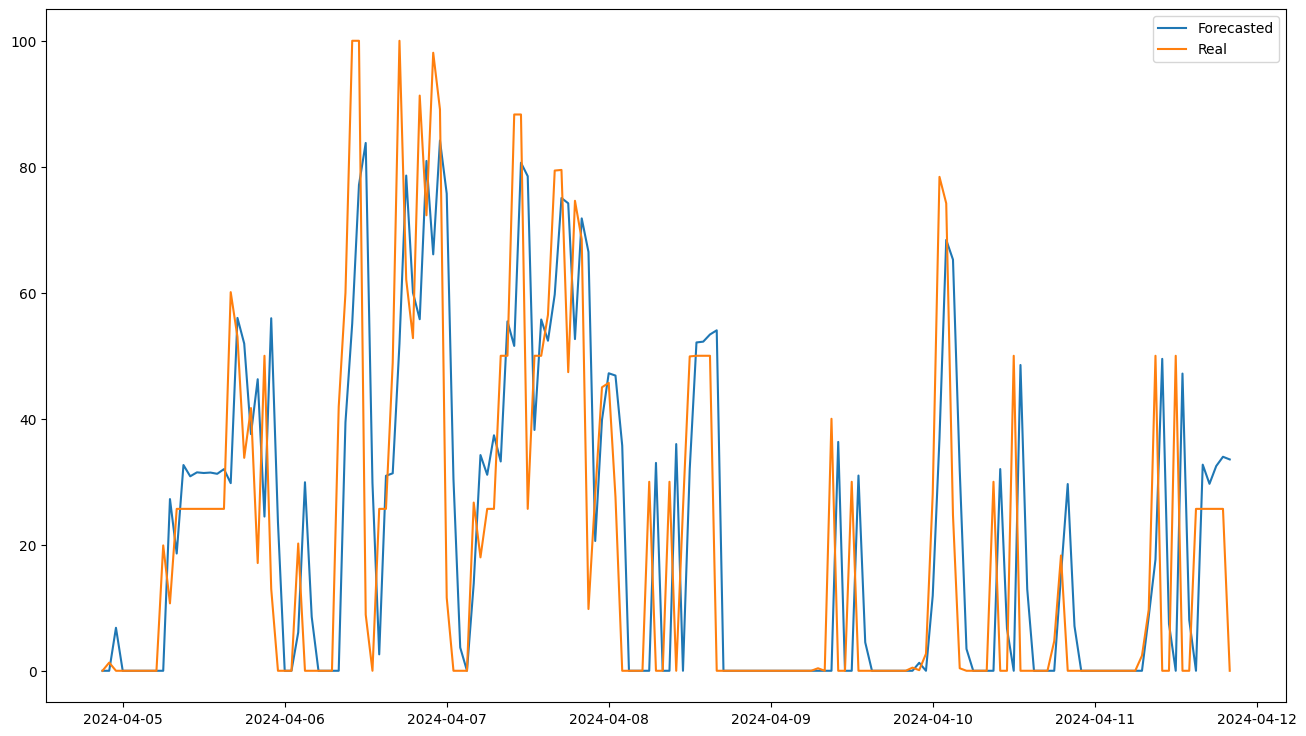

In [11]:
plt.figure(figsize= (16, 9))
plt.plot(test_results["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

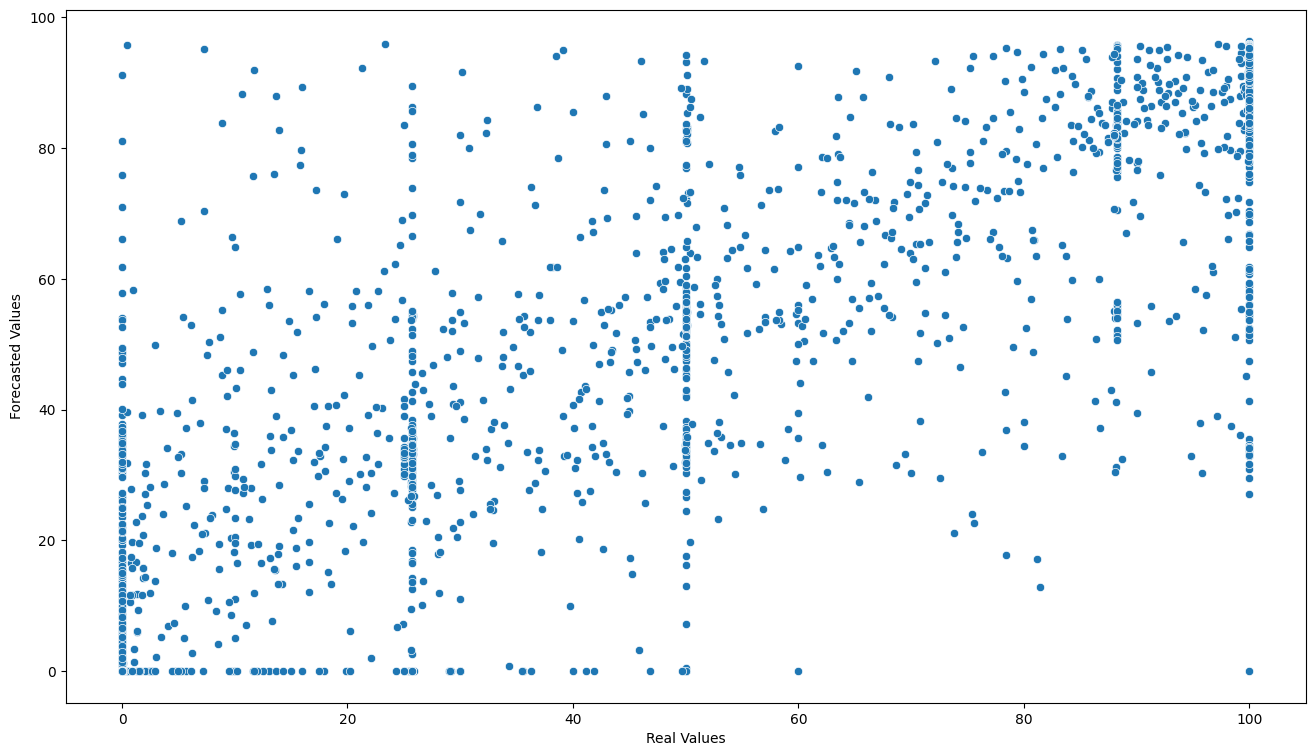

In [12]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = test_results)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [13]:
mse = mean_squared_error(test_results["Real Data"], test_results["Val Predictions"])
print(f" Mean Squared Error = {round(mse, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse), 5)}")

ss_total = np.sum((test_results["Real Data"] - test_results["Real Data"].mean()) ** 2)
residual = np.sum((test_results["Real Data"] - test_results["Val Predictions"]) ** 2)
r_squared = 1 - (residual / ss_total)

r_squared

 Mean Squared Error = 421.47504 
 Root Mean Squared Error = 20.52986


0.6925705010672529